In [19]:
# Cargar archivos
ventas = pd.read_excel('/content/ventas_excel.xlsx')
clientes = pd.read_csv('/content/clientes_sql.csv')

# Mostrar primeras filas
display(ventas.head())
display(clientes.head())

,ID_Venta,Fecha,ClienteID,ProductoID,Región,Monto
0,1,2025/03/10,13,1,Sur,1000.0
1,2,15-04-2025,7,6,Este,200.0
2,3,2025/03/10,14,9,Este,1000.0
3,4,05/02/2025,20,7,Este,200.0
4,5,NaN,17,9,Sur,200.0


,ClienteID,Nombre,Región,Edad
0,1,Cliente_1,Oeste,35
1,2,Cliente_2,Este,63
2,3,Cliente_3,Sur,40
3,4,Cliente_4,Norte,43
4,5,Cliente_5,Sur,28



# Análisis de Ventas e Integración de Clientes

**Objetivo:**  
Este notebook integra los datos de ventas (`ventas_excel.xlsx`) y clientes (`clientes_sql.csv`), realiza limpieza de datos, genera estadísticas descriptivas y visualiza las ventas por región.

---


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt


In [21]:

# Cargar archivos
ventas = pd.read_excel('/content/ventas_excel.xlsx')
clientes = pd.read_csv('clientes_sql.csv')

# Mostrar primeras filas
display(ventas.head())
display(clientes.head())


,ID_Venta,Fecha,ClienteID,ProductoID,Región,Monto
0,1,2025/03/10,13,1,Sur,1000.0
1,2,15-04-2025,7,6,Este,200.0
2,3,2025/03/10,14,9,Este,1000.0
3,4,05/02/2025,20,7,Este,200.0
4,5,NaN,17,9,Sur,200.0


,ClienteID,Nombre,Región,Edad
0,1,Cliente_1,Oeste,35
1,2,Cliente_2,Este,63
2,3,Cliente_3,Sur,40
3,4,Cliente_4,Norte,43
4,5,Cliente_5,Sur,28



## Limpieza de datos

En esta sección se:
- Corrigen formatos de fechas.
- Eliminan duplicados.
- Completan valores faltantes si aplica.
- Asegura la consistencia de tipos de datos antes de la integración.


In [22]:

# Convertir fechas a formato correcto
if 'Fecha' in ventas.columns:
    ventas['Fecha'] = pd.to_datetime(ventas['Fecha'], errors='coerce')

# Eliminar duplicados
ventas = ventas.drop_duplicates()
clientes = clientes.drop_duplicates()

# Llenar valores faltantes
ventas = ventas.fillna({'Ventas': ventas['Ventas'].mean()}) if 'Ventas' in ventas.columns else ventas

# Confirmar limpieza
display(ventas.info())
display(clientes.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ID_Venta    50 non-null     int64         
 1   Fecha       11 non-null     datetime64[ns]
 2   ClienteID   50 non-null     int64         
 3   ProductoID  50 non-null     int64         
 4   Región      43 non-null     object        
 5   Monto       43 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 2.5+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ClienteID  20 non-null     int64 
 1   Nombre     20 non-null     object
 2   Región     20 non-null     object
 3   Edad       20 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 772.0+ bytes


None

In [29]:

# Calcular estadísticas descriptivas
promedio = df['Ventas'].mean()
maximo = df['Ventas'].max()
minimo = df['Ventas'].min()

print(f"Ventas promedio: {promedio:.2f}")
print(f"Venta máxima: {maximo:.2f}")
print(f"Venta mínima: {minimo:.2f}")


Ventas promedio: 416.28
Venta máxima: 1000.00
Venta mínima: 100.00



## Integración de datasets

Se realiza la unión entre `ventas` y `clientes` usando la columna `ClienteID`.


In [30]:

# Unir datasets
df = pd.merge(ventas, clientes, on='ClienteID', how='inner')
display(df.head())


,ID_Venta,Fecha,ClienteID,ProductoID,Región_x,Monto,Nombre,Región_y,Edad
0,1,2025-03-10,13,1,Sur,1000.0,Cliente_13,Este,37
1,2,NaT,7,6,Este,200.0,Cliente_7,Oeste,53
2,3,2025-03-10,14,9,Este,1000.0,Cliente_14,Oeste,32
3,4,NaT,20,7,Este,200.0,Cliente_20,Norte,59
4,5,NaT,17,9,Sur,200.0,Cliente_17,Este,55



## Estadísticas descriptivas

Cálculo de las ventas promedio, máxima y mínima.



## Visualización: Ventas totales por región

Se genera un gráfico de barras que muestra las ventas agrupadas por región.


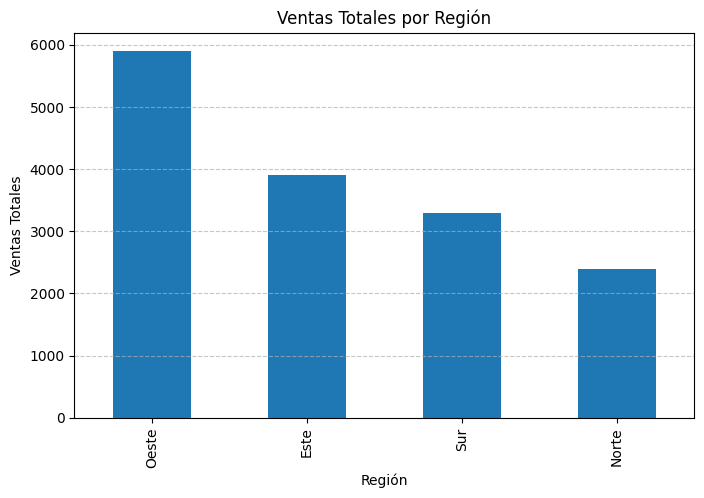

In [32]:
# Agrupar ventas por región
ventas_region = df.groupby('Región_x')['Monto'].sum().sort_values(ascending=False)

# Gráfico de barras
plt.figure(figsize=(8,5))
ventas_region.plot(kind='bar')
plt.title('Ventas Totales por Región')
plt.xlabel('Región')
plt.ylabel('Ventas Totales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Conclusiones

- Se integraron correctamente los datos de ventas y clientes.  
- Se identificaron los valores promedio, máximo y mínimo de ventas.  
- El gráfico de barras permite observar las diferencias regionales en el volumen de ventas.

---  
**Autor:** Luis. E. Garcés  
**Herramienta:** Python + Jupyter Notebook
